In [1]:
import INUVisionCall as ivc

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


# **호출 구조 지정**

카메라 호출 = 칼라 뎁스 인트린직 뎁스 스케일 반환

서치 = 코스 서치 = 객체들의 6D를 전부 담은 테이블, 클래스별 반환

위치 반환 = 카메라에서 가까운 객체별로 위치 반환

[INFO] 카메라 데이터 캡처 중...
[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


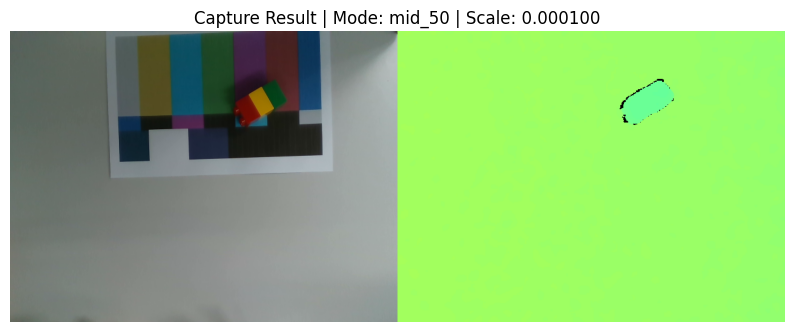

✅ 카메라 스트리밍 안전 종료 완료.
[INFO] 전체 객체 탐색(Search Wide) 실행 중...
🎯 [SUCCESS] 8개의 타겟 객체 마스크 병합 완료
✂️ [INFO] 억제됨: '2x2_yellow' (면적:1416)가 '2x2_green' (면적:2171)에 77.0% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 7개
 - 🏷️ 4x2_blue (신뢰도: 0.66)
 - 🏷️ 4x2_green (신뢰도: 0.87)
 - 🏷️ 4x2_blue (신뢰도: 0.78)
 - 🏷️ 4x2_blue (신뢰도: 0.87)
 - 🏷️ 2x2_blue (신뢰도: 0.54)
 - 🏷️ 2x2_green (신뢰도: 0.77)
 - 🏷️ 2x2_red (신뢰도: 0.60)


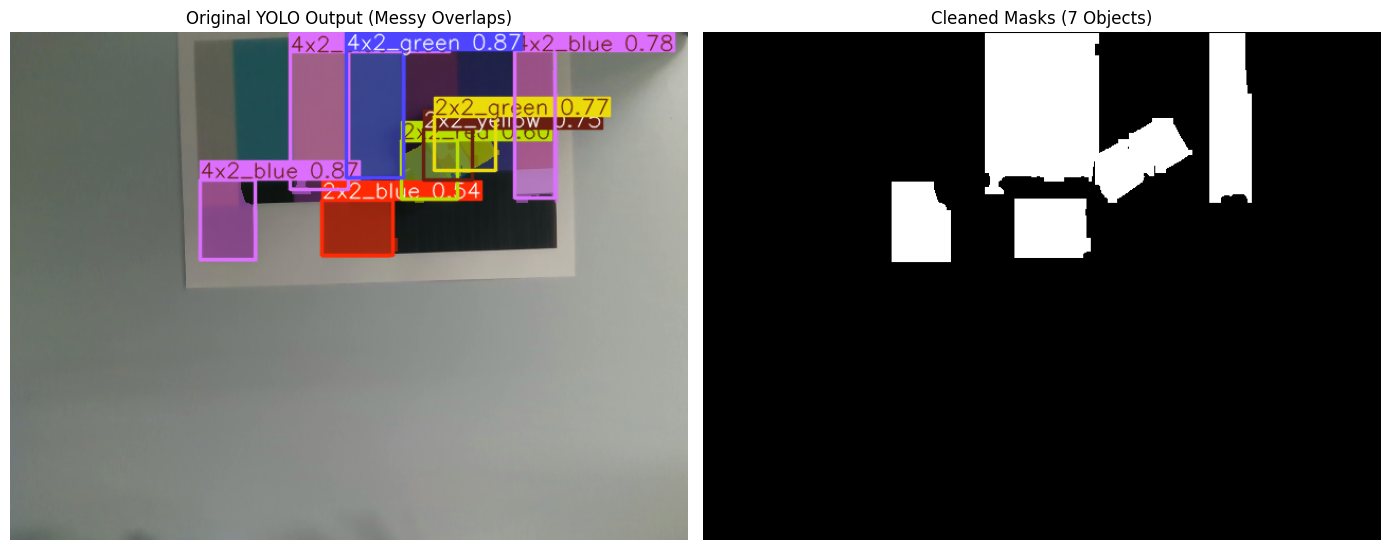


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: 0.018x + -0.001y + 1.000z + 0.494 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 0개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.36). '4x2_blue' -> '2x2_blue'

[INFO] Convex Hull 객체 마스크 제외 후 바닥 평면 재추정 중...
✅ Plane: -0.0175x + 0.0005y + -0.9998z + 0.4941 = 0

[INFO] Convex Hull mask 기준 3D OBB 생성 중...

[3D OBB 중심 좌표]
 - idx 00 | 4x2_blue | center(mm)=(-29.3, -138.4, 482.6) | h=24.0mm | points=715
 - idx 01 | 4x2_green | center(mm)=(13.1, -143.1, 481.9) | h=24.0mm | points=621
 - idx 02 | 4x2_blue | center(mm)=(136.4, -134.7, 479.7) | h=24.0mm | points=513
 - idx 03 | 2x2_blue | center(mm)=(-102.2, -56.1, 483.9) | h=24.0mm | points=329
 - idx 04 | 2x2_blue | center(mm)=(-0.7, -51.0, 482.2) | h=24.0mm | points=338
 - idx 05 | 2x2_green | center(mm)=(78.5, -112.0, 476.7) | h=32.0mm | points=236
 - idx 06 | 2x2_red | center(mm)=(51.1, -96.7, 477.4) | h=31.6mm | points=230

[INFO] 3D OBB + Object Coordinate Axes 표시

[INFO] R

In [2]:
# 1. 매니저 객체 생성
vision = ivc.VisionManager()

# 2. 카메라 캡처 (리턴값 받을 필요 없이 알아서 내부에 저장됨)
vision.capture_camera(visualize=True)

# 3. 서치 실행
vision.run_search(visualize=True)

# 4. 원하는 타겟 ID로 포즈 추출 (예: 7번 = 4x2_blue, 두 번째 객체 = local_id 1)
my_target_pose = vision.get_pose_by_id(target_id=5, local_id=0)

if my_target_pose is not None:
    x, y, z = my_target_pose["x_mm"], my_target_pose["y_mm"], my_target_pose["z_mm"]
    roll, pitch, yaw = my_target_pose["roll_deg"], my_target_pose["pitch_deg"], my_target_pose["yaw_deg"]

    print("--- 6D Pose Result ---")
    print(f"class: {my_target_pose['class_name']}")
    print(f"local_id: {my_target_pose['local_id']}")
    print(f"global_idx: {my_target_pose.get('global_idx', 'N/A')}")
    print(f"XYZ mm: {x:.1f}, {y:.1f}, {z:.1f}")
    print(f"RPY deg: {roll:.2f}, {pitch:.2f}, {yaw:.2f}")
    print("----------------------")

# # 다른 ID도 연속해서 바로바로 찾을 수 있습니다.
# battery_pose = vision.get_pose_by_id(target_id=34)

[INFO] 카메라 데이터 캡처 중...
[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


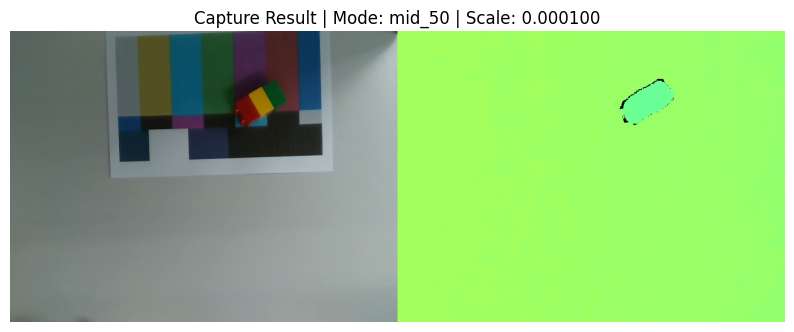

✅ 카메라 스트리밍 안전 종료 완료.
[INFO] 조립체 객체 탐색(Search Assembly) 실행 중...

[INFO] assembly contour object count: 1


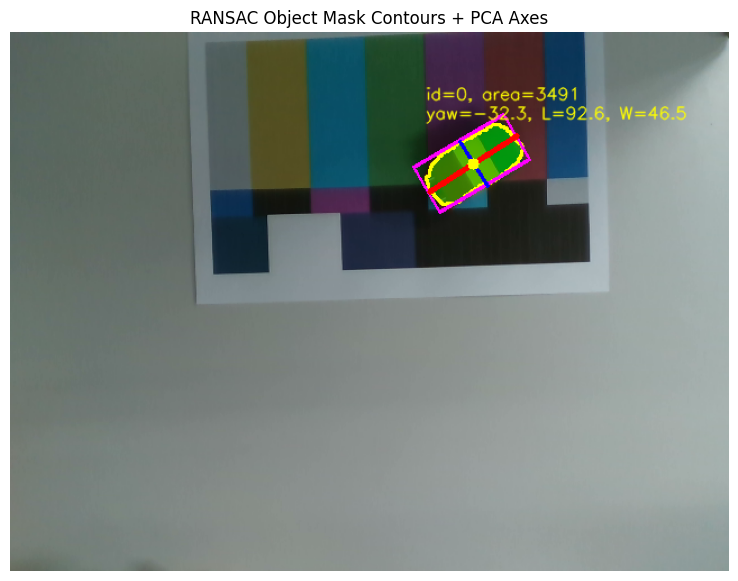

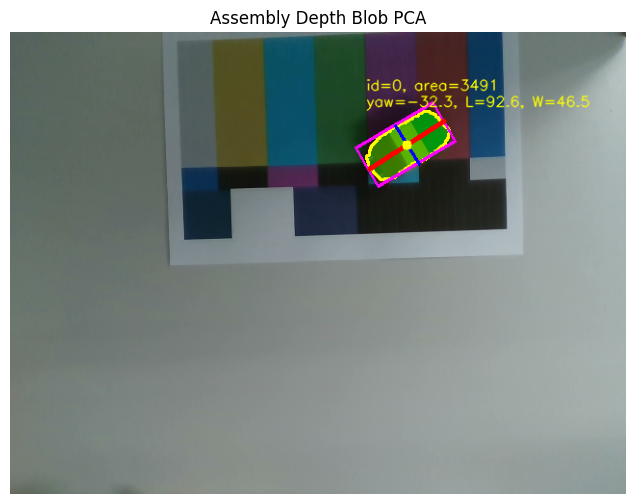

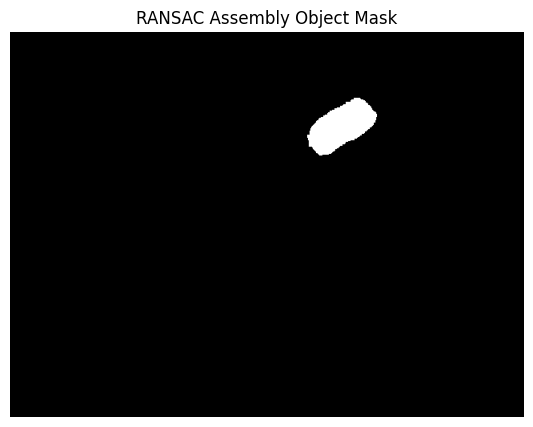

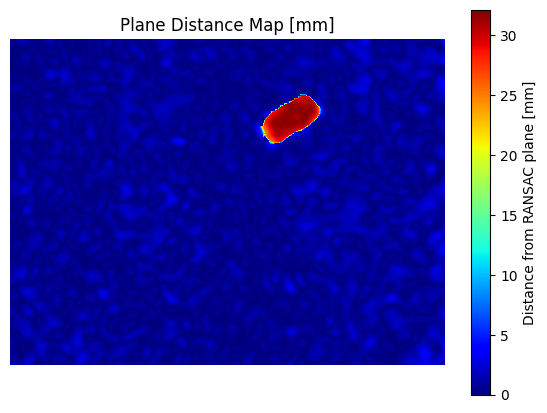


[Assembly Pose Table]
local_id 00 | assembly     | XYZ mm=(   63.4,   -99.2,   462.9) | RPY deg=(   0.00,    0.00,  -32.25)

[INFO] 타겟 ID [999] ➔ 클래스명 ['assembly'] 변환 완료
[INFO] ivl.get_nearest_6d_pose_by_class 사용 실패. 직접 class_index에서 검색합니다.
[INFO] reason: 'x_m'
--- 6D Pose Result ---
class: assembly
local_id: 0
global_idx: 0
XYZ mm: 63.4, -99.2, 462.9
RPY deg: 0.00, 0.00, -32.25
----------------------


In [3]:
vision = ivc.VisionManager()

vision.capture_camera(mode="mid_50", visualize=True)

pose_table, class_index = vision.run_search_assembly(
    visualize=True,
    object_min_plane_dist=0.010,
    min_contour_area=80
)

pose = vision.get_pose_by_id(target_id=999, local_id=0)